# Loan Default Risk Analysis Using Python

## Project Overview

This project analyses a dataset of 148,670 mortgage loans to identify borrower and loan characteristics associated with default risk.

The analysis uses Python to explore data quality, investigate relationships between key risk factors and loan default, and identify combinations of characteristics associated with elevated default rates.

## 1. Setup and Data Loading

The required Python libraries are imported and the mortgage loan dataset is loaded into a pandas DataFrame. The first five rows are displayed to provide an initial view of the dataset and its variables.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Loan_Default.csv")
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## 2. Data Understanding

Before conducting the analysis, the structure of the dataset is examined. This includes checking the number of observations and variables, reviewing column names and inspecting data types and non-null values.

In [5]:
df.shape

(148670, 34)

In [6]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

## 3. Data Quality and Cleaning

The dataset is assessed for missing values, duplicate records and potential data quality issues before further analysis. Missingness is examined both overall and in relation to loan default status, as missing data may itself contain information about the outcome.

In [9]:
missing_values = df.isnull().sum()

missing_values

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [10]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

Upfront_charges              26.664425
Interest_rate_spread         24.644515
rate_of_interest             24.509989
dtir1                        16.224524
LTV                          10.155378
property_value               10.155378
income                        6.154571
loan_limit                    2.249277
approv_in_adv                 0.610749
submission_of_application     0.134526
age                           0.134526
loan_purpose                  0.090133
Neg_ammortization             0.081388
term                          0.027578
Region                        0.000000
total_units                   0.000000
Security_Type                 0.000000
Status                        0.000000
co-applicant_credit_type      0.000000
Credit_Score                  0.000000
credit_type                   0.000000
ID                            0.000000
Secured_by                    0.000000
occupancy_type                0.000000
construction_type             0.000000
year                     

In [11]:
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
missing_summary.sort_values('Missing_Percent', ascending=False)

,Missing_Count,Missing_Percent
Upfront_charges,39642,26.664425
Interest_rate_spread,36639,24.644515
rate_of_interest,36439,24.509989
dtir1,24121,16.224524
property_value,15098,10.155378
LTV,15098,10.155378
income,9150,6.154571
loan_limit,3344,2.249277
approv_in_adv,908,0.610749
age,200,0.134526


In [12]:
df.duplicated().sum()

df['ID'].duplicated().sum()

0

In [13]:
df['Status'].value_counts()
df['Status'].value_counts(normalize=True) * 100

Status
0    75.355485
1    24.644515
Name: proportion, dtype: float64

In [14]:
df.groupby('Status')['rate_of_interest'].apply(lambda x: x.isnull().mean() * 100)

Status
0     0.000000
1    99.454134
Name: rate_of_interest, dtype: float64

In [15]:
columns_to_check = [
    'rate_of_interest',
    'Interest_rate_spread',
    'Upfront_charges',
    'dtir1',
    'LTV',
    'property_value',
    'income'
]

df.groupby('Status')[columns_to_check].apply(
    lambda x: x.isnull().mean() * 100
)

,rate_of_interest,Interest_rate_spread,Upfront_charges,dtir1,LTV,property_value,income
Status,,,,,,,
0,0.000000,0.0,2.817077,6.972177,0.001785,0.001785,7.061438
1,99.454134,100.0,99.582412,44.515407,41.201998,41.201998,3.381643


In [16]:
(df['LTV'].isnull() == df['property_value'].isnull()).mean() * 100

100.0

In [17]:
df_clean = df.copy()

In [18]:
df_clean['year'].value_counts()

year
2019    148670
Name: count, dtype: int64

In [19]:
df_clean['ID'].nunique()

148670

In [20]:
df_clean = df_clean.drop(columns=[
    'ID',
    'year',
    'rate_of_interest',
    'Interest_rate_spread',
    'Upfront_charges'
])

In [21]:
df_clean.shape

(148670, 29)

In [22]:
missing_clean = pd.DataFrame({
    'Missing_Count': df_clean.isnull().sum(),
    'Missing_Percent': (df_clean.isnull().sum() / len(df_clean)) * 100
})

missing_clean = missing_clean[missing_clean['Missing_Count'] > 0]
missing_clean.sort_values('Missing_Percent', ascending=False)

,Missing_Count,Missing_Percent
dtir1,24121,16.224524
property_value,15098,10.155378
LTV,15098,10.155378
income,9150,6.154571
loan_limit,3344,2.249277
approv_in_adv,908,0.610749
age,200,0.134526
submission_of_application,200,0.134526
loan_purpose,134,0.090133
Neg_ammortization,121,0.081388


In [23]:
df_clean['loan_type'].value_counts()
df_clean['age'].value_counts(dropna=False)
df_clean['Region'].value_counts()

Region
North         74722
south         64016
central        8697
North-East     1235
Name: count, dtype: int64

In [24]:
categorical_cols = df_clean.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts(dropna=False))


--- loan_limit ---
loan_limit
cf     135348
ncf      9978
NaN      3344
Name: count, dtype: int64

--- Gender ---
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64

--- approv_in_adv ---
approv_in_adv
nopre    124621
pre       23141
NaN         908
Name: count, dtype: int64

--- loan_type ---
loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

--- loan_purpose ---
loan_purpose
p3     55934
p4     54799
p1     34529
p2      3274
NaN      134
Name: count, dtype: int64

--- Credit_Worthiness ---
Credit_Worthiness
l1    142344
l2      6326
Name: count, dtype: int64

--- open_credit ---
open_credit
nopc    148114
opc        556
Name: count, dtype: int64

--- business_or_commercial ---
business_or_commercial
nob/c    127908
b/c       20762
Name: count, dtype: int64

--- Neg_ammortization ---
Neg_ammortization
not_neg    133420
neg_amm     15129
NaN           121
Name: 

In [25]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amount,148670.0,331117.743997,183909.310127,16500.000000,196500.00000,296500.00000,436500.000000,3576500.00
term,148629.0,335.136582,58.409084,96.000000,360.00000,360.00000,360.000000,360.00
property_value,133572.0,497893.465696,359935.315562,8000.000000,268000.00000,418000.00000,628000.000000,16508000.00
income,139520.0,6957.338876,6496.586382,0.000000,3720.00000,5760.00000,8520.000000,578580.00
Credit_Score,148670.0,699.789103,115.875857,500.000000,599.00000,699.00000,800.000000,900.00
LTV,133572.0,72.746457,39.967603,0.967478,60.47486,75.13587,86.184211,7831.25
Status,148670.0,0.246445,0.430942,0.000000,0.00000,0.00000,0.000000,1.00
dtir1,124549.0,37.732932,10.545435,5.000000,31.00000,39.00000,45.000000,61.00


In [26]:
df_clean['LTV'].sort_values(ascending=False).head(10)

16951     7831.250000
55286     6706.250000
47807     5206.250000
65238     4706.250000
46287     2956.250000
123343    2331.250000
43348      263.541667
30837      237.500000
27473      237.500000
136154     220.362903
Name: LTV, dtype: float64

In [27]:
df_clean[df_clean['LTV'] > 200][
    ['loan_amount', 'property_value', 'LTV', 'Status']
].sort_values('LTV', ascending=False).head(20)

,loan_amount,property_value,LTV,Status
16951,626500,8000.0,7831.250000,0
55286,536500,8000.0,6706.250000,0
47807,416500,8000.0,5206.250000,0
65238,376500,8000.0,4706.250000,0
46287,236500,8000.0,2956.250000,1
123343,186500,8000.0,2331.250000,0
43348,126500,48000.0,263.541667,1
27473,66500,28000.0,237.500000,1
30837,66500,28000.0,237.500000,1
136154,546500,248000.0,220.362903,0


# 4. Exploratory Risk Analysis

This section investigates how borrower and loan characteristics are associated with default risk. Default rates are compared across credit score, loan-to-value (LTV), debt-to-income (DTI), loan type and other characteristics to identify potential risk drivers.

## 4.1 Credit Score and Default Risk

Borrowers are grouped into credit score bands to examine whether default rates vary with credit quality.

In [29]:
df_clean['Credit_Score_Band'] = pd.cut(
    df_clean['Credit_Score'],
    bins=[0, 599, 699, 799, 900],
    labels=['Low', 'Fair', 'Good', 'Excellent']
)

In [30]:
df_clean['Credit_Score_Band'].value_counts().sort_index()

Credit_Score_Band
Low          37190
Fair         37200
Good         36811
Excellent    37469
Name: count, dtype: int64

In [31]:
credit_default_rate = (
    df_clean.groupby('Credit_Score_Band', observed=True)['Status']
    .mean() * 100
)

credit_default_rate

Credit_Score_Band
Low          24.630277
Fair         24.483871
Good         24.286219
Excellent    25.170141
Name: Status, dtype: float64

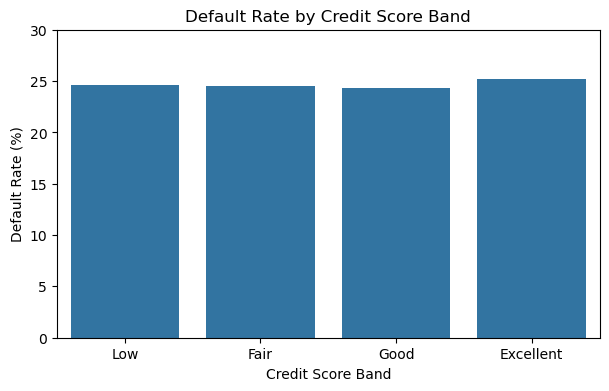

In [32]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=credit_default_rate.index,
    y=credit_default_rate.values
)

plt.title('Default Rate by Credit Score Band')
plt.xlabel('Credit Score Band')
plt.ylabel('Default Rate (%)')
plt.ylim(0, 30)

plt.show()

**Key finding:** Default rates are relatively similar across credit score bands, ranging from approximately 24.3% to 25.2%. Surprisingly, the Excellent credit score group has the highest observed default rate (25.2%), suggesting that credit score alone is not a strong discriminator of default risk in this dataset.

## 4.2 Loan-to-Value (LTV) and Default Risk

Loans are grouped into loan-to-value (LTV) bands to examine how the size of the loan relative to the property value is associated with default risk.

In [34]:
df_clean['LTV_Band'] = pd.cut(
    df_clean['LTV'],
    bins=[0, 60, 80, 90, 100, float('inf')],
    labels=['≤60', '60-80', '80-90', '90-100', '>100']
)

In [35]:
df_clean['LTV_Band'].value_counts().sort_index()

LTV_Band
≤60       32565
60-80     49895
80-90     26153
90-100    23160
>100       1799
Name: count, dtype: int64

In [36]:
ltv_default_rate = (
    df_clean.groupby('LTV_Band', observed=True)['Status']
    .mean() * 100
)

ltv_default_rate

LTV_Band
≤60       13.922923
60-80     12.939172
80-90     18.437655
90-100    19.689119
>100      65.091718
Name: Status, dtype: float64

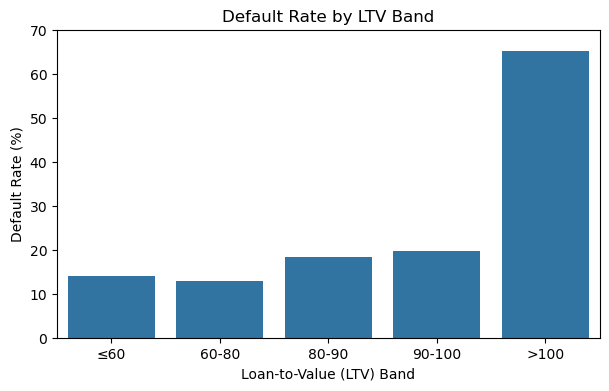

In [37]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=ltv_default_rate.index,
    y=ltv_default_rate.values
)

plt.title('Default Rate by LTV Band')
plt.xlabel('Loan-to-Value (LTV) Band')
plt.ylabel('Default Rate (%)')
plt.ylim(0, 70)

plt.show()

**Key finding:** Default risk increases substantially at very high LTV levels. Loans with an LTV above 100% have a default rate of approximately 65.1%, compared with 12.9% for loans with an LTV between 60% and 80%. This suggests that high LTV is a strong indicator of default risk in this dataset.

## 4.3 Debt-to-Income (DTI) and Default Risk

Borrowers are grouped into debt-to-income (DTI) bands to examine whether higher levels of debt relative to income are associated with increased default risk.

In [39]:
df_clean['DTI_Band'] = pd.cut(
    df_clean['dtir1'],
    bins=[0, 20, 30, 40, 50, float('inf')],
    labels=['≤20', '20-30', '30-40', '40-50', '>50']
)

In [40]:
df_clean['DTI_Band'].value_counts().sort_index()

DTI_Band
≤20       8165
20-30    19805
30-40    41861
40-50    46079
>50       8639
Name: count, dtype: int64

In [41]:
dti_default_rate = (
    df_clean.groupby('DTI_Band', observed=True)['Status']
    .mean() * 100
)

dti_default_rate

DTI_Band
≤20      24.200857
20-30    12.057561
30-40    12.204677
40-50    15.547212
>50      42.736428
Name: Status, dtype: float64

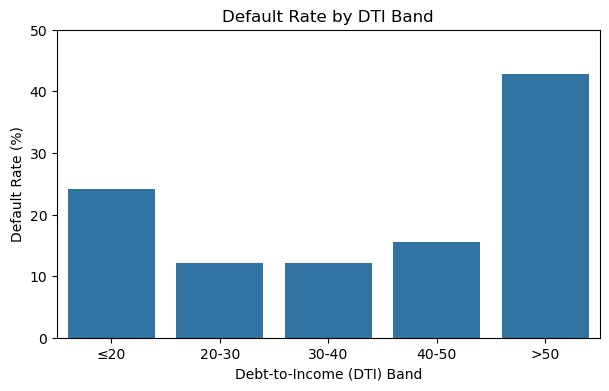

In [42]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=dti_default_rate.index,
    y=dti_default_rate.values
)

plt.title('Default Rate by DTI Band')
plt.xlabel('Debt-to-Income (DTI) Band')
plt.ylabel('Default Rate (%)')
plt.ylim(0, 50)

plt.show()

**Key finding:** Borrowers with a DTI above 50% have the highest default rate at approximately 42.7%. Default rates are considerably lower for borrowers in the 20-40% range, at around 12%. The elevated default rate among borrowers with very high DTI suggests that debt burden is an important indicator of default risk.

## 4.4 Loan Characteristics

Loan type and loan purpose are analysed to determine whether different types of lending are associated with different levels of default risk.

In [44]:
loan_type_analysis = (
    df_clean.groupby('loan_type')['Status']
    .agg(['count', 'mean'])
)

loan_type_analysis['Default_Rate'] = loan_type_analysis['mean'] * 100

loan_type_analysis

,count,mean,Default_Rate
loan_type,,,
type1,113173,0.227749,22.774867
type2,20762,0.345439,34.543878
type3,14735,0.250560,25.055989


In [45]:
loan_purpose_analysis = (
    df_clean.groupby('loan_purpose')['Status']
    .agg(['count', 'mean'])
)

loan_purpose_analysis['Default_Rate'] = loan_purpose_analysis['mean'] * 100

loan_purpose_analysis

,count,mean,Default_Rate
loan_purpose,,,
p1,34529,0.258768,25.876799
p2,3274,0.330788,33.078803
p3,55934,0.250223,25.022348
p4,54799,0.229749,22.974872


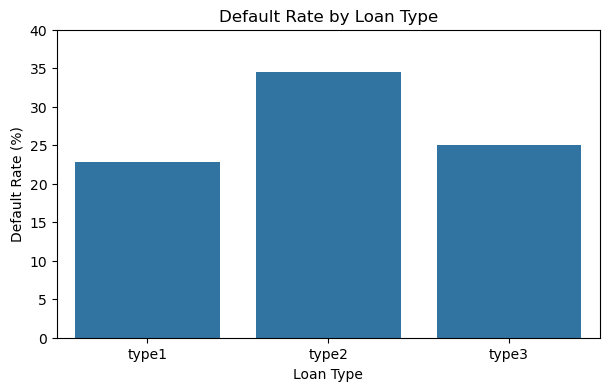

In [46]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=loan_type_analysis.index,
    y=loan_type_analysis['Default_Rate']
)

plt.title('Default Rate by Loan Type')
plt.xlabel('Loan Type')
plt.ylabel('Default Rate (%)')
plt.ylim(0, 40)

plt.show()

**Key finding:** Default rates vary across loan characteristics. Type 2 loans have the highest default rate at approximately 34.5%, compared with 22.8% for Type 1 and 25.1% for Type 3 loans. Loan purpose P2 also has the highest default rate among the purpose categories at approximately 33.1%. These results suggest that loan characteristics may help identify higher-risk segments.

In [48]:
pd.crosstab(
    df_clean['loan_type'],
    df_clean['business_or_commercial']
)

business_or_commercial,b/c,nob/c
loan_type,,
type1,0,113173
type2,20762,0
type3,0,14735


**Note:** Loan Type 2 corresponds entirely to business/commercial loans in this dataset, while Types 1 and 3 correspond to non-business/commercial loans. These variables therefore contain overlapping information and should not be treated as independent risk factors.

## 4.5 Income and Loan Amount

Income and loan amount are compared between defaulted and non-defaulted loans to investigate whether borrower income or loan size differs according to default status.

In [50]:
df_clean.groupby('Status')['income'].agg([
    'count',
    'median',
    'mean'
])

,count,median,mean
Status,,,
0,104120,6000.0,7204.014214
1,35400,4860.0,6231.806780


In [51]:
df_clean.groupby('Status')['loan_amount'].agg([
    'count',
    'median',
    'mean'
])

,count,median,mean
Status,,,
0,112031,306500.0,334990.774875
1,36639,276500.0,319275.184912


# 5. Combined Risk Factor Analysis

Individual risk factors are combined to investigate whether particular borrower and loan characteristics identify higher-risk segments. High LTV, high DTI and Type 2 loans are used to construct risk indicators and compare default rates across different combinations.

In [53]:
df_clean['High_LTV'] = (df_clean['LTV'] > 100).astype(int)

df_clean['High_DTI'] = (df_clean['dtir1'] > 50).astype(int)

df_clean['High_Risk_Loan_Type'] = (
    df_clean['loan_type'] == 'type2'
).astype(int)

## 5.1 Preparing the Combined Risk Sample

Loans with missing LTV or DTI values are excluded from the combined risk analysis so that each observation can be consistently assessed against all selected risk factors. This leaves 124,547 loans for analysis.

In [55]:
risk_analysis = df_clean.dropna(subset=['LTV', 'dtir1']).copy()

risk_analysis.shape

(124547, 35)

## 5.2 Defining Risk Factors

Three risk indicators are defined based on patterns identified in the exploratory analysis:

- **High LTV:** LTV greater than 100%
- **High DTI:** DTI greater than 50
- **High-Risk Loan Type:** Type 2 loans

Each indicator is coded as 1 when the condition is met and 0 otherwise. These indicators are then combined to examine how default risk varies across different risk profiles.

In [57]:
risk_analysis['High_LTV'] = (
    risk_analysis['LTV'] > 100
).astype(int)

risk_analysis['High_DTI'] = (
    risk_analysis['dtir1'] > 50
).astype(int)

risk_analysis['High_Risk_Loan_Type'] = (
    risk_analysis['loan_type'] == 'type2'
).astype(int)

risk_analysis['Risk_Factor_Count'] = (
    risk_analysis['High_LTV']
    + risk_analysis['High_DTI']
    + risk_analysis['High_Risk_Loan_Type']
)

## 5.3 Risk Factor Count

Three binary risk indicators are used:

- **High LTV:** LTV greater than 100%
- **High DTI:** DTI greater than 50
- **High-Risk Loan Type:** Type 2 loan

These indicators are summed to create a risk factor count ranging from 0 to 3.

In [59]:
risk_analysis['Risk_Factor_Count'].value_counts().sort_index()

Risk_Factor_Count
0    104137
1     15884
2      4446
3        80
Name: count, dtype: int64

In [60]:
risk_factor_analysis = (
    risk_analysis.groupby('Risk_Factor_Count')['Status']
    .agg(['count', 'mean'])
)

risk_factor_analysis['Default_Rate'] = (
    risk_factor_analysis['mean'] * 100
)

risk_factor_analysis

,count,mean,Default_Rate
Risk_Factor_Count,,,
0,104137,0.125450,12.545013
1,15884,0.359041,35.904054
2,4446,0.333333,33.333333
3,80,1.000000,100.000000


In [61]:
combination_analysis = (
    risk_analysis.groupby(
        ['High_LTV', 'High_DTI', 'High_Risk_Loan_Type']
    )['Status']
    .agg(['count', 'mean'])
)

combination_analysis['Default_Rate'] = (
    combination_analysis['mean'] * 100
)

combination_analysis.sort_values(
    'Default_Rate',
    ascending=False
)

count      mean  Default_Rate
High_LTV High_DTI High_Risk_Loan_Type                                
1        0        1                       259  1.000000    100.000000
         1        1                        80  1.000000    100.000000
         0        0                       900  0.610000     61.000000
0        1        0                      4372  0.546432     54.643184
1        1        0                       266  0.451128     45.112782
0        1        1                      3921  0.281306     28.130579
         0        1                     10612  0.260554     26.055409
                  0                    104137  0.125450     12.545013

In [62]:
combination_plot = combination_analysis.reset_index()

combination_plot['Risk_Combination'] = combination_plot.apply(
    lambda row:
        ('High LTV + ' if row['High_LTV'] else '') +
        ('High DTI + ' if row['High_DTI'] else '') +
        ('Type 2' if row['High_Risk_Loan_Type'] else ''),
    axis=1
)

combination_plot['Risk_Combination'] = (
    combination_plot['Risk_Combination']
    .str.rstrip(' +')
    .replace('', 'No Selected Risk Factors')
)

combination_plot = combination_plot.sort_values(
    'Default_Rate',
    ascending=True
)

In [63]:
combination_plot[
    ['Risk_Combination', 'count', 'Default_Rate']
]

,Risk_Combination,count,Default_Rate
0,No Selected Risk Factors,104137,12.545013
1,Type 2,10612,26.055409
3,High DTI + Type 2,3921,28.130579
6,High LTV + High DTI,266,45.112782
2,High DTI,4372,54.643184
4,High LTV,900,61.000000
5,High LTV + Type 2,259,100.000000
7,High LTV + High DTI + Type 2,80,100.000000


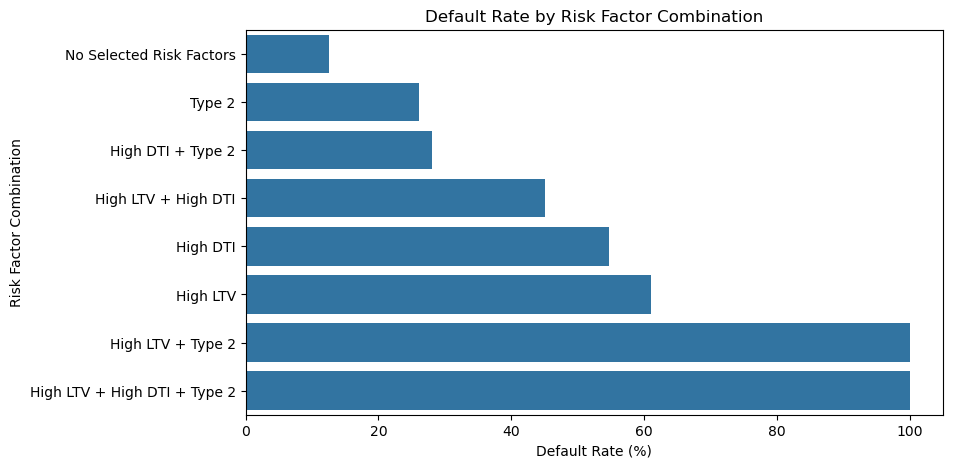

In [64]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=combination_plot,
    x='Default_Rate',
    y='Risk_Combination'
)

plt.title('Default Rate by Risk Factor Combination')
plt.xlabel('Default Rate (%)')
plt.ylabel('Risk Factor Combination')
plt.xlim(0, 105)

plt.show()

## 5.4 Combined Risk Findings

**Key finding:** The combined analysis shows that default risk varies substantially depending on the specific risk factors present, rather than simply increasing with the number of risk factors.

Loans with no selected risk factors have the lowest default rate at approximately 12.5%. High LTV is particularly associated with elevated default risk, with high-LTV-only loans recording a default rate of 61.0%.

The highest observed default rates occur for loans combining high LTV with Type 2: both **High LTV + Type 2** and **High LTV + High DTI + Type 2** record a 100% default rate. However, these groups contain only 259 and 80 loans respectively, so the results should be interpreted cautiously due to their relatively small sample sizes.

Overall, the analysis suggests that the **specific combination of risk characteristics is more informative than the number of risk factors alone**, with high LTV emerging as a particularly important indicator of default risk.

# 6. Conclusions and Key Insights

This analysis examined 148,670 mortgage loans to identify borrower and loan characteristics associated with default risk. The overall default rate in the dataset is approximately 24.6%.

### Key Findings

- **Loan-to-value (LTV) is a strong risk indicator.** Loans with an LTV above 100% have a default rate of approximately 65.1%, compared with 12.9% for loans with an LTV between 60% and 80%.

- **Very high debt-to-income (DTI) is associated with increased default risk.** Loans with a DTI above 50 have a default rate of approximately 42.7%, substantially higher than the 12.1% observed for borrowers with a DTI between 20 and 30.

- **Type 2 loans represent a higher-risk segment.** Their default rate is approximately 34.5%, compared with 22.8% for Type 1 and 25.1% for Type 3 loans.

- **Credit score alone provides limited separation of default risk in this dataset.** Default rates remain close to 24-25% across all four credit score bands.

- **Income differs between defaulting and non-defaulting borrowers.** Defaulting borrowers have a median income of approximately 4,860 compared with 6,000 among non-defaulting borrowers.

- **Risk factors interact in important ways.** Loans with no selected risk factors have a default rate of approximately 12.5%, while several combinations involving high LTV show substantially higher default rates. High LTV combined with Type 2 records a 100% default rate in this sample, although the relatively small group size means this result should be interpreted cautiously.

### Overall Conclusion

The analysis suggests that default risk cannot be explained by a single borrower characteristic. LTV, DTI and loan type provide useful indicators of higher-risk lending, while combinations of these characteristics reveal particularly high-risk segments.

For practical risk analysis, these findings support assessing multiple borrower and loan characteristics together rather than relying on measures such as credit score in isolation.